In [14]:
import data_funcs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
drug_data, landmark_genes = data_funcs.read_drug_data()
dis_data = data_funcs.read_dis_data(landmark_genes)

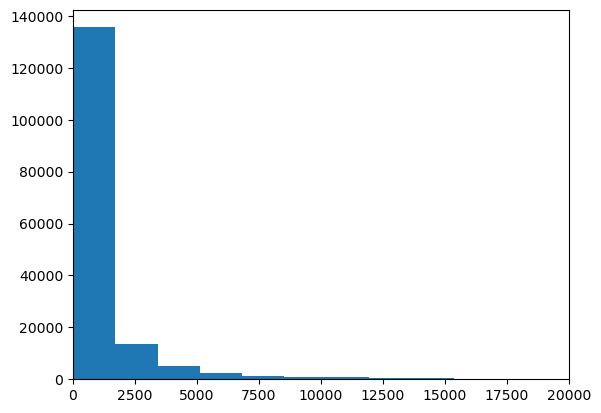

In [24]:
values = []
for disease_sample in dis_data.columns:
    if data_funcs.get_dis_meta(disease_sample, 'type') == 'rnaseq':
        values.extend(dis_data[disease_sample].values)
plt.hist(values, bins=1000)
plt.xlim([0, 20000])
plt.show()


In [126]:
# https://github.com/ShawnLYU/Quantile_Normalize
def quantile_normalize(df_input):
    df = df_input.copy()
    #compute rank
    dic = {}
    for col in df:
        dic.update({col : sorted(df[col])})
    sorted_df = pd.DataFrame(dic)
    rank = sorted_df.mean(axis = 1).tolist()
    #sort
    for col in df:
        t = np.searchsorted(np.sort(df[col]), df[col])
        df[col] = [rank[i] for i in t]
    return df

In [113]:
data = {
    'S1': [5, 2, 3, 4],
    'S2': [4, 1, 4, 2],
    'S3': [3, 4, 6, 8]
}
x = pd.DataFrame(data)
x.index = ['A', 'B', 'C', 'D']
x

,S1,S2,S3
A,5,4,3
B,2,1,4
C,3,4,6
D,4,2,8


In [127]:
quantile_normalize(x)

,S1,S2,S3
A,5.666667,4.666667,2.000000
B,2.000000,2.000000,3.000000
C,3.000000,4.666667,4.666667
D,4.666667,3.000000,5.666667


In [136]:
ma_samples = []
for disease_sample in dis_data.columns:
    if data_funcs.get_dis_meta(disease_sample, 'type') == 'microarray':
        ma_samples.append(disease_sample)
ma_data = dis_data[ma_samples]

# ma_data = ma_data.iloc[:,:4]
# ma_data.dropna(inplace=True)
# ma_data = np.log2(ma_data + 1)
ma_data

Disease Samples,GSM484450,GSM484453,GSM484454,GSM484457,GSM484462,GSM484477,GSM484479,GSM409137,GSM409138,GSM409139,...,GSM484369,GSM484370,GSM484371,GSM484372,GSM484373,GSM484374,GSM484375,GSM484377,GSM484378,GSM484379
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,2.471917,2.533743,2.400866,2.381452,2.605398,2.541487,2.469798,-0.003972,12.492237,12.029694,...,2.427295,2.510762,2.230893,2.339730,2.440679,2.226160,2.239478,2.233720,2.357473,2.400148
466,-0.089527,-0.115732,-0.101819,-0.018170,-0.119542,-0.017855,-0.119616,2.507151,5.879857,4.681379,...,-0.015839,-0.186701,-0.033675,-0.030788,-0.010621,-0.093223,-0.081889,-0.102400,-0.039658,-0.071411
6009,2.795884,2.934972,2.715569,2.724173,2.900263,2.672966,2.882289,2.054041,2.573850,2.019334,...,2.814330,2.892419,2.822818,2.715261,2.820262,2.827360,2.929149,2.864576,2.671555,2.712769
2309,0.386953,0.401729,0.382215,0.358355,0.405478,0.416604,0.399945,2.553713,24.828009,21.781526,...,0.388284,0.314173,0.350951,0.368174,0.348411,0.422487,0.375252,0.368631,0.369105,0.385801
387,2.809470,2.938254,2.717415,2.726580,2.902211,2.831692,2.885613,2.320439,9.213339,9.518605,...,2.816931,2.897124,2.873904,2.717124,2.823444,2.830011,2.932543,2.868629,2.685413,2.715894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,-0.031962,-0.032757,-0.016701,-0.037461,-0.000073,-0.018842,-0.016641,1.695483,13.165315,10.398895,...,-0.032934,-0.094748,-0.083755,-0.050408,-0.029681,-0.012274,0.003039,-0.031765,-0.040208,-0.020644
51293,-0.080359,-0.084295,-0.095572,-0.098345,-0.100528,-0.104295,-0.087225,0.097122,0.111427,0.619225,...,-0.084137,0.045156,0.104215,-0.098860,-0.084205,-0.063165,-0.041316,-0.083557,-0.108537,-0.062210
10962,1.247066,1.312529,1.263275,1.225147,1.337165,1.359816,1.290781,11.378471,7.710375,6.381312,...,1.276199,1.295063,1.178623,1.190391,1.238874,1.241794,1.151568,1.123090,1.187795,1.310469


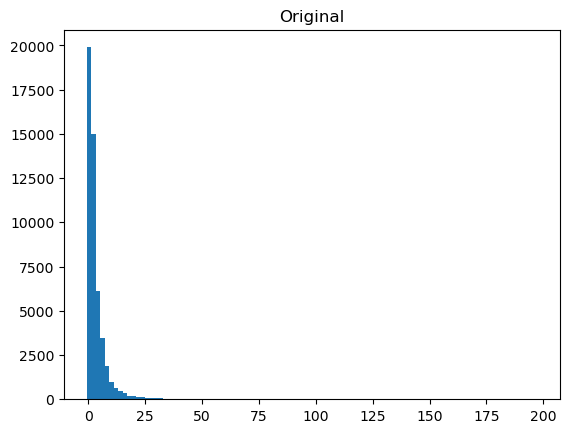

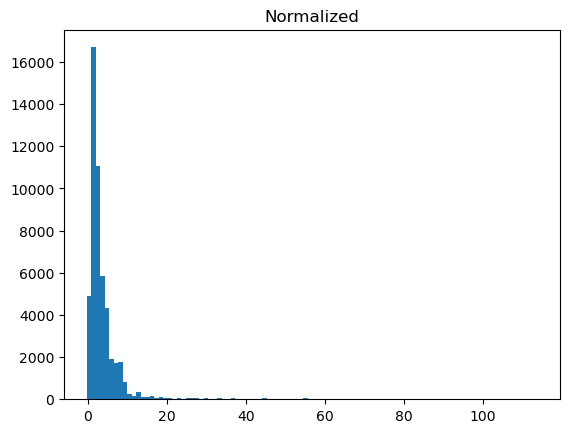

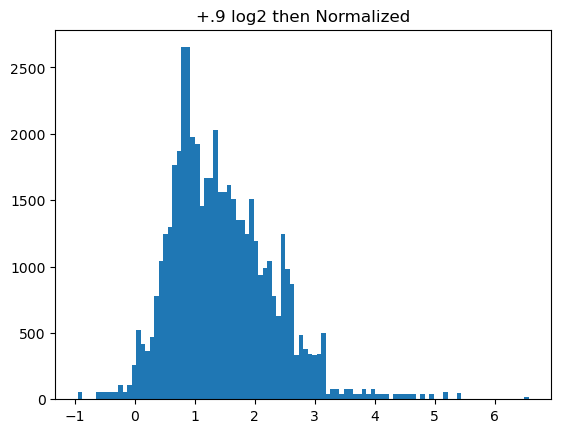

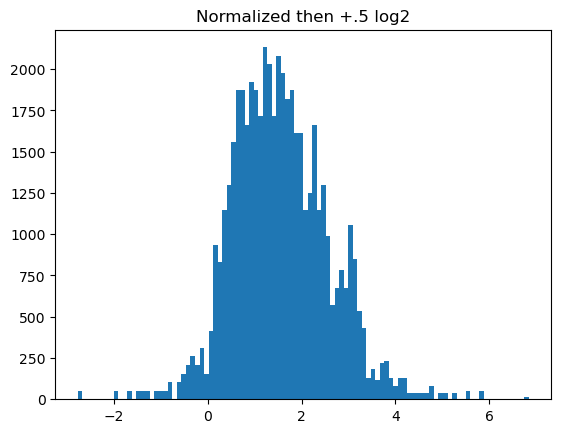

In [159]:
plt.hist(ma_data.values.flatten(), bins=100)
plt.title('Original')
plt.show()

normalized = quantile_normalize(ma_data)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized')
plt.show()

normalized = quantile_normalize(np.log2(ma_data + .9))
plt.hist(normalized.values.flatten(), bins=100)
plt.title('+.9 log2 then Normalized')
plt.show()

normalized = np.log2(quantile_normalize(ma_data) + .5)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized then +.5 log2')
plt.show()